## Task4: Location-based analysis

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import folium

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("Dataset .csv")
df.head(10)

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229
5,18189371,Din Tai Fung,162,Mandaluyong City,"Ground Floor, Mega Fashion Hall, SM Megamall, ...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056314,14.583764,Chinese,...,Botswana Pula(P),No,No,No,No,3,4.4,Green,Very Good,336
6,6300781,Buffet 101,162,Pasay City,"Building K, SM By The Bay, Sunset Boulevard, M...","SM by the Bay, Mall of Asia Complex, Pasay City","SM by the Bay, Mall of Asia Complex, Pasay Cit...",120.979667,14.531333,"Asian, European",...,Botswana Pula(P),Yes,No,No,No,4,4.0,Green,Very Good,520
7,6301290,Vikings,162,Pasay City,"Building B, By The Bay, Seaside Boulevard, Mal...","SM by the Bay, Mall of Asia Complex, Pasay City","SM by the Bay, Mall of Asia Complex, Pasay Cit...",120.979333,14.540000,"Seafood, Filipino, Asian, European",...,Botswana Pula(P),Yes,No,No,No,4,4.2,Green,Very Good,677
8,6300010,Spiral - Sofitel Philippine Plaza Manila,162,Pasay City,"Plaza Level, Sofitel Philippine Plaza Manila, ...","Sofitel Philippine Plaza Manila, Pasay City","Sofitel Philippine Plaza Manila, Pasay City, P...",120.980090,14.552990,"European, Asian, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.9,Dark Green,Excellent,621
9,6314987,Locavore,162,Pasig City,"Brixton Technology Center, 10 Brixton Street, ...",Kapitolyo,"Kapitolyo, Pasig City",121.056532,14.572041,Filipino,...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,532


In [3]:
print("Latitude Range:")
print(df['Latitude'].min(), "-", df['Latitude'].max())

print()

print("Longitude Range:")
print(df['Longitude'].min(), "-", df['Longitude'].max())

Latitude Range:
-41.330428 - 55.97698

Longitude Range:
-157.948486 - 174.8320893


In [4]:
city_counts = df['City'].value_counts()

city_counts.head(10)

City
New Delhi       5473
Gurgaon         1118
Noida           1080
Faridabad        251
Ghaziabad         25
Bhubaneshwar      21
Lucknow           21
Ahmedabad         21
Amritsar          21
Guwahati          21
Name: count, dtype: int64

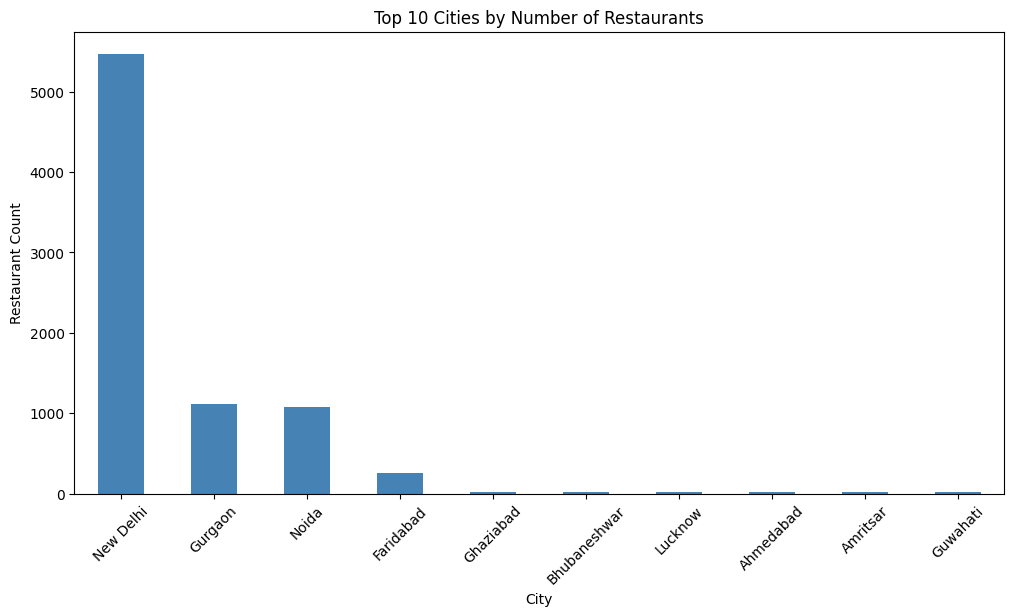

In [5]:
plt.figure(figsize=(12,6))

city_counts.head(10).plot(
    kind='bar',
    color='steelblue'
)

plt.title("Top 10 Cities by Number of Restaurants")
plt.xlabel("City")
plt.ylabel("Restaurant Count")

plt.xticks(rotation=45)

plt.show()

In [6]:
city_rating = (
    df.groupby('City')['Aggregate rating']
      .mean()
      .sort_values(ascending=False)
)

city_rating.head(10)

City
Inner City          4.900000
Quezon City         4.800000
Makati City         4.650000
Pasig City          4.633333
Mandaluyong City    4.625000
Beechworth          4.600000
London              4.535000
Taguig City         4.525000
Secunderabad        4.500000
Lincoln             4.500000
Name: Aggregate rating, dtype: float64

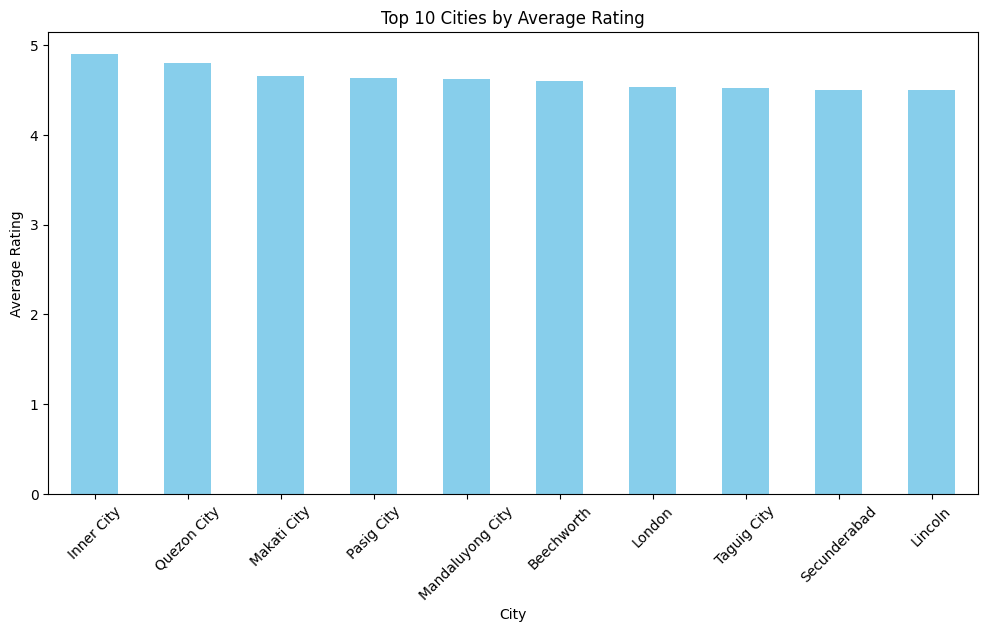

In [8]:
plt.figure(figsize=(12,6))

city_rating.head(10).plot(
    kind='bar',
    color='skyblue'
)

plt.title("Top 10 Cities by Average Rating")
plt.ylabel("Average Rating")

plt.xticks(rotation=45)

plt.show()

In [9]:
cost_city = (
    df.groupby('City')['Average Cost for two']
      .mean()
      .sort_values(ascending=False)
)

cost_city.head(10)

City
Jakarta             308437.500000
Tangerang           250000.000000
Bogor               160000.000000
Bandung             150000.000000
Pasay City            3333.333333
Colombo               2375.000000
Mandaluyong City      2000.000000
Panchkula             2000.000000
Taguig City           1725.000000
Hyderabad             1361.111111
Name: Average Cost for two, dtype: float64

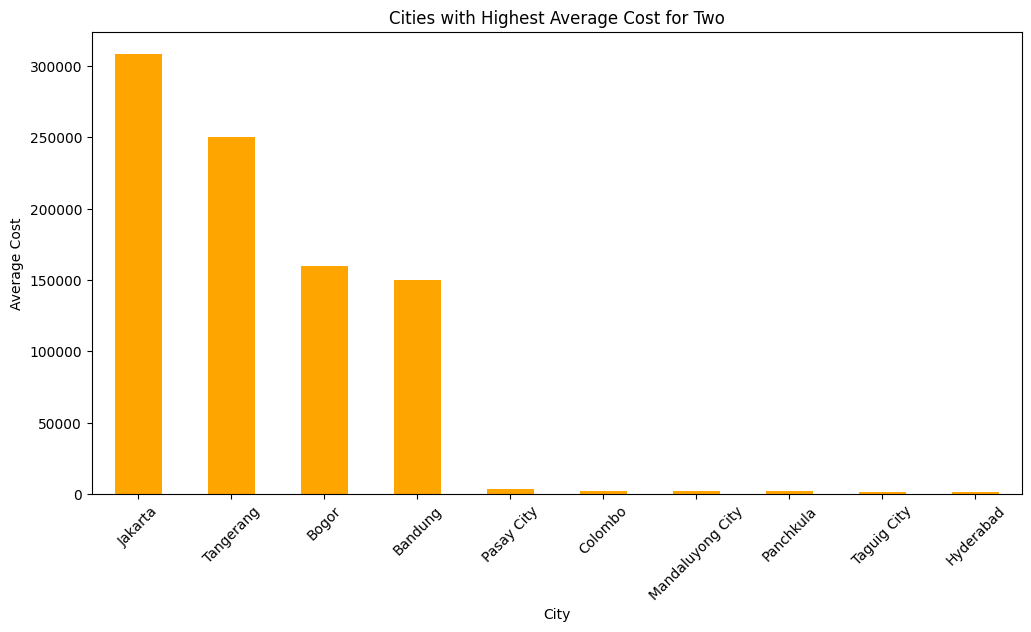

In [10]:
plt.figure(figsize=(12,6))

cost_city.head(10).plot(
    kind='bar',
    color='orange'
)

plt.title("Cities with Highest Average Cost for Two")
plt.ylabel("Average Cost")

plt.xticks(rotation=45)

plt.show()

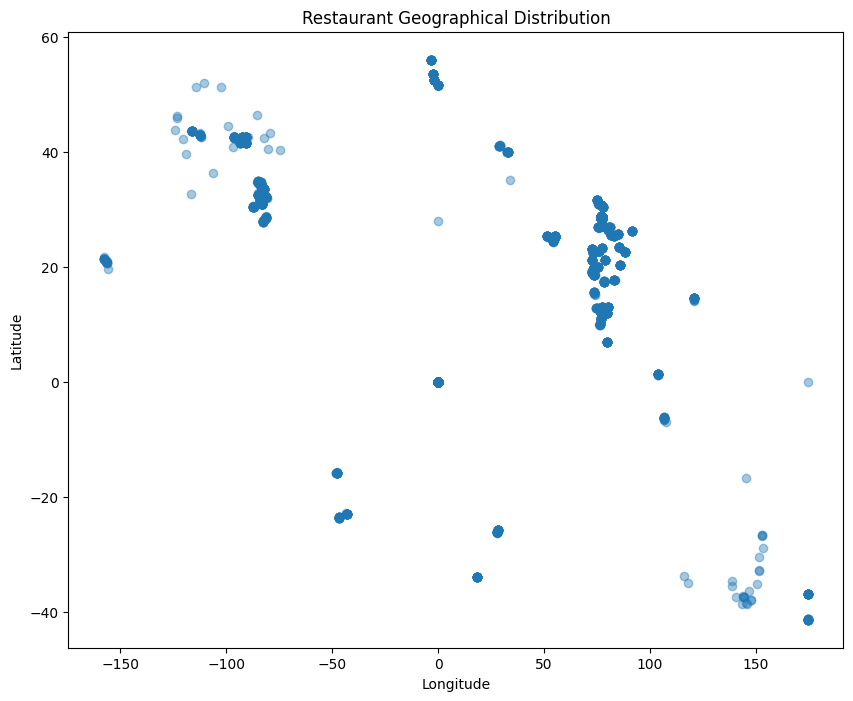

In [11]:
plt.figure(figsize=(10,8))

plt.scatter(
    df['Longitude'],
    df['Latitude'],
    alpha=0.4
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Restaurant Geographical Distribution")

plt.show()

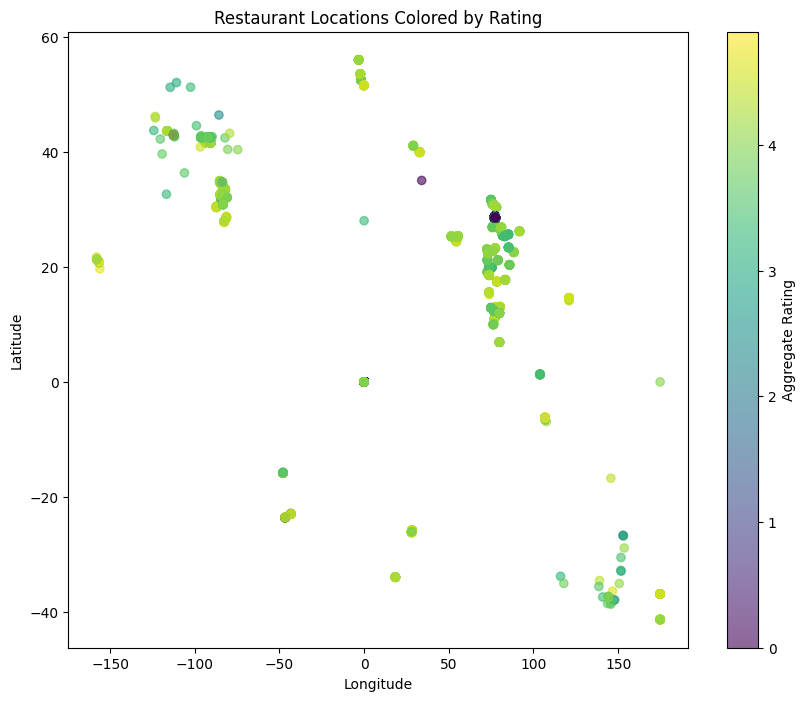

In [12]:
plt.figure(figsize=(10,8))

scatter = plt.scatter(
    df['Longitude'],
    df['Latitude'],
    c=df['Aggregate rating'],
    cmap='viridis',
    alpha=0.6
)

plt.colorbar(
    scatter,
    label='Aggregate Rating'
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.title("Restaurant Locations Colored by Rating")

plt.show()

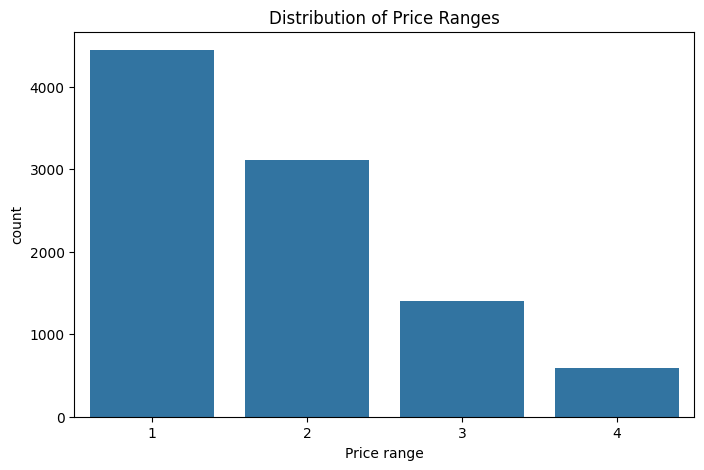

In [13]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='Price range',
    data=df
)

plt.title("Distribution of Price Ranges")

plt.show()

In [14]:
locality_count = (
    df['Locality']
      .value_counts()
      .head(10)
)

print(locality_count)

Locality
Connaught Place        122
Rajouri Garden          99
Shahdara                87
Defence Colony          86
Malviya Nagar           85
Pitampura               85
Mayur Vihar Phase 1     84
Rajinder Nagar          81
Safdarjung              80
Satyaniketan            79
Name: count, dtype: int64


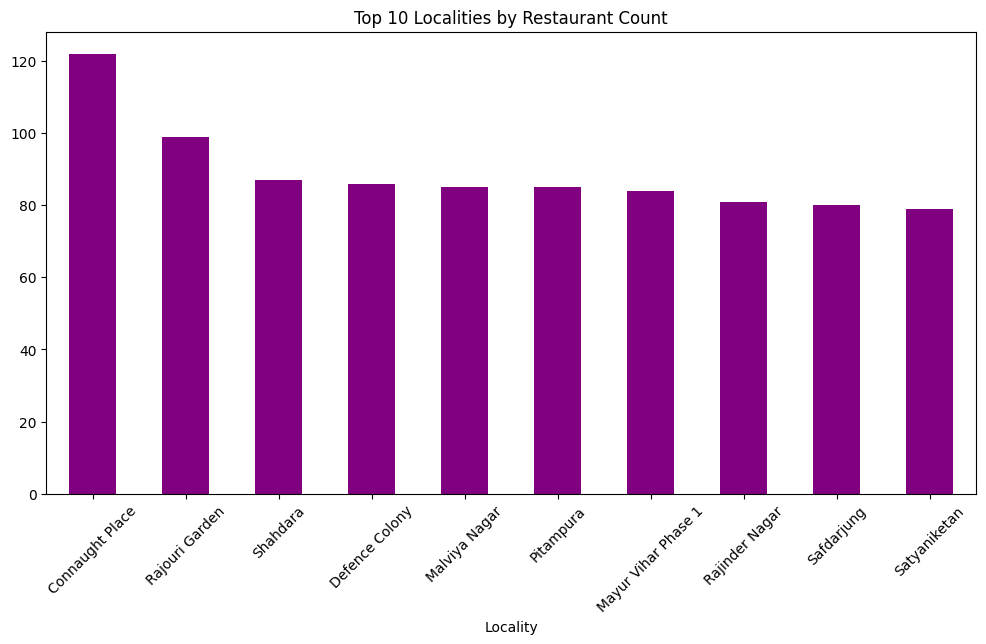

In [15]:
plt.figure(figsize=(12,6))

locality_count.plot(
    kind='bar',
    color='purple'
)

plt.title("Top 10 Localities by Restaurant Count")

plt.xticks(rotation=45)

plt.show()

In [16]:
city_summary = (
    df.groupby('City')
      .agg({
          'Aggregate rating':'mean',
          'Votes':'mean',
          'Average Cost for two':'mean'
      })
      .head(20)
)

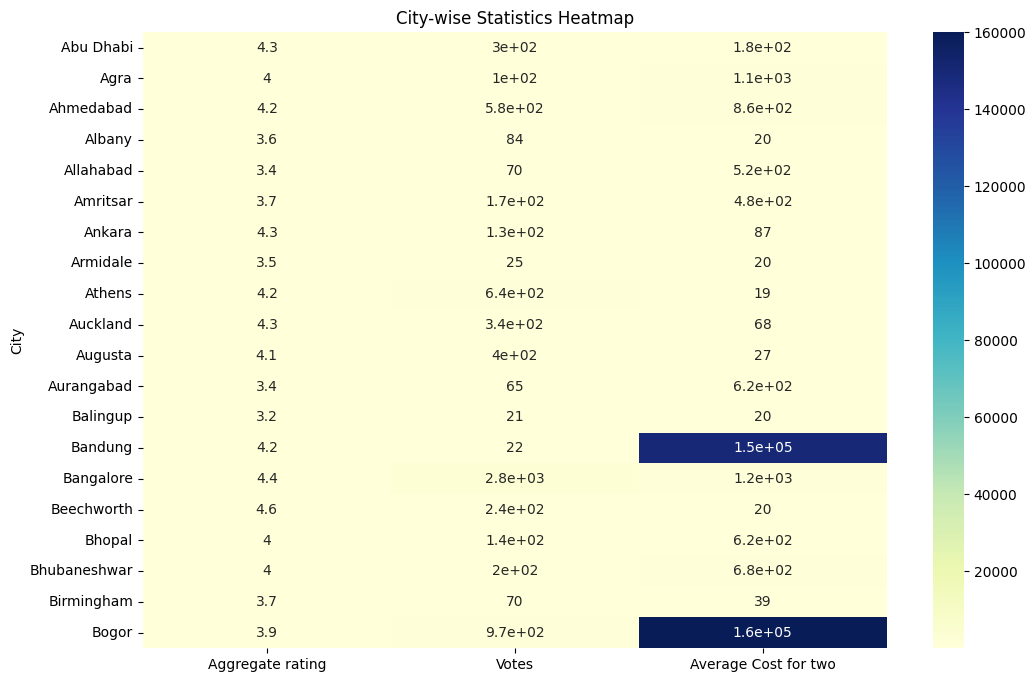

In [17]:
plt.figure(figsize=(12,8))

sns.heatmap(
    city_summary,
    annot=True,
    cmap='YlGnBu'
)

plt.title("City-wise Statistics Heatmap")

plt.show()